In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom
import scipy.stats as st
import seaborn as sns

# Lección 2: Probabilidad y estadística

In [34]:
# Configuración de reproducibilidad
np.random.seed(42)

# Simulación del diseño muestral
n = 120
data = {
    'ID': range(1, n + 1),
    'Horas_Sueno': np.random.normal(6.5, 1.5, n).round(1),
    'Dias_Ejercicio': np.random.randint(0, 8, n),
    'Facultad': np.random.choice(['Ingeniería', 'Salud', 'Artes', 'Sociales'], n)
}

df = pd.DataFrame(data)
df.to_csv('dataset_habitos_saludables.csv', index=False)

## Definición de eventos para cálculos
# Evento A: Sueño Insuficiente (< 7 horas)
# Evento B: Sedentario (<= 2 días de ejercicio)
A = df['Horas_Sueno'] < 7
B = df['Dias_Ejercicio'] <= 2

# Cálculo de probabilidades básicas
p_a = A.mean()
p_b = B.mean()
p_interseccion = (A & B).mean()
p_union = (A | B).mean()
p_complemento_a = 1 - p_a

print(f"Probabilidades Calculadas:")
print(f"- P(A) [Sueño Insuficiente]: {p_a:.2f}")
print(f"- P(B) [Sedentario]: {p_b:.2f}")
print(f"- P(A ∩ B) [Intersección]: {p_interseccion:.2f}")
print(f"- P(A ∪ B) [Unión]: {p_union:.2f}")
print(f"- P(A') [Complemento de A]: {p_complemento_a:.2f}")

Probabilidades Calculadas:
- P(A) [Sueño Insuficiente]: 0.67
- P(B) [Sedentario]: 0.40
- P(A ∩ B) [Intersección]: 0.29
- P(A ∪ B) [Unión]: 0.78
- P(A') [Complemento de A]: 0.33


# Lección 3: Distribución de probabilidad

Análisis de Distribuciones:
- P(Sueño > 8h): 0.1213
- P(Ejercicio = 3 días): 0.2747


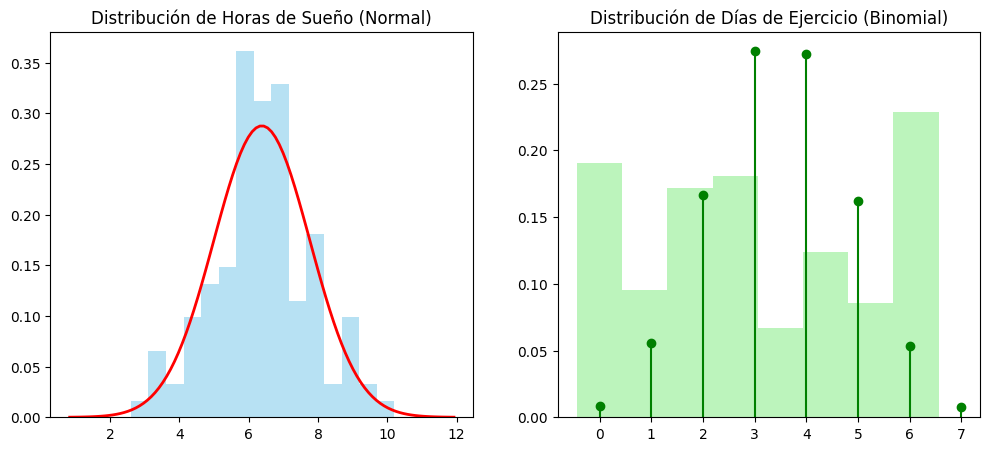

In [35]:
# Parámetros para Distribución Normal (Sueño)
mu_sueno = df['Horas_Sueno'].mean()
sigma_sueno = df['Horas_Sueno'].std()

# Probabilidad de que un estudiante duerma > 8 horas (P(X > 8))
p_optimo_sueno = 1 - norm.cdf(8, mu_sueno, sigma_sueno)

# Parámetros para Distribución Binomial (Ejercicio)
n_dias = 7

# Estimamos p como la media de días dividido por el total de días
p_ejercicio = df['Dias_Ejercicio'].mean() / n_dias

# Probabilidad de que haga ejercicio exactamente 3 días (P(X = 3))
p_3_dias = binom.pmf(3, n_dias, p_ejercicio)

print(f"Análisis de Distribuciones:")
print(f"- P(Sueño > 8h): {p_optimo_sueno:.4f}")
print(f"- P(Ejercicio = 3 días): {p_3_dias:.4f}")

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma Sueño vs Normal
x_sueno = np.linspace(mu_sueno - 4*sigma_sueno, mu_sueno + 4*sigma_sueno, 100)
ax[0].hist(df['Horas_Sueno'], bins=15, density=True, alpha=0.6, color='skyblue')
ax[0].plot(x_sueno, norm.pdf(x_sueno, mu_sueno, sigma_sueno), 'r-', lw=2)
ax[0].set_title('Distribución de Horas de Sueño (Normal)')

# Histograma Ejercicio vs Binomial
x_ej = np.arange(0, 8)
ax[1].hist(df['Dias_Ejercicio'], bins=8, density=True, alpha=0.6, color='lightgreen', align='left')
ax[1].stem(x_ej, binom.pmf(x_ej, n_dias, p_ejercicio), linefmt='g-', markerfmt='go', basefmt=" ")
ax[1].set_title('Distribución de Días de Ejercicio (Binomial)')

plt.show()

# Lección 4: Distribución muestral y teorema del límite central

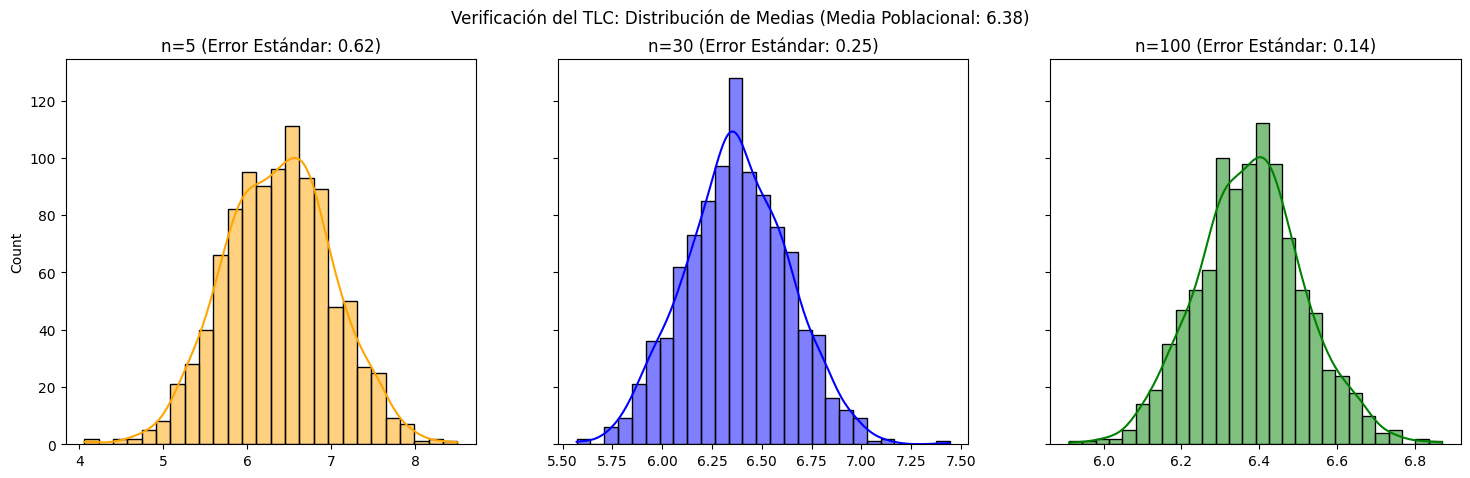

Desviación Estándar Real (SE) para n=100: 0.1372
Error Estándar Teórico (sigma/sqrt(n)): 0.1387


In [36]:
# Consideramos nuestra columna como la población
poblacion = df['Horas_Sueno']
media_pob = poblacion.mean()
std_pob = poblacion.std()

def generar_distribucion_muestral(data, n_size, iterations=1000):
    return [data.sample(n_size, replace=True).mean() for _ in range(iterations)]

# Generamos medias para diferentes tamaños de muestra (n)
muestras_n5 = generar_distribucion_muestral(poblacion, 5)
muestras_n30 = generar_distribucion_muestral(poblacion, 30)
muestras_n100 = generar_distribucion_muestral(poblacion, 100)

# Visualización y Comparación
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.histplot(muestras_n5, kde=True, ax=axes[0], color='orange')
axes[0].set_title(f'n=5 (Error Estándar: {std_pob/np.sqrt(5):.2f})')

sns.histplot(muestras_n30, kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'n=30 (Error Estándar: {std_pob/np.sqrt(30):.2f})')

sns.histplot(muestras_n100, kde=True, ax=axes[2], color='green')
axes[2].set_title(f'n=100 (Error Estándar: {std_pob/np.sqrt(100):.2f})')

plt.suptitle(f'Verificación del TLC: Distribución de Medias (Media Poblacional: {media_pob:.2f})')
plt.show()

# Comparación de dispersión (Desviación estándar de las medias)
print(f"Desviación Estándar Real (SE) para n=100: {np.std(muestras_n100):.4f}")
print(f"Error Estándar Teórico (sigma/sqrt(n)): {std_pob/np.sqrt(100):.4f}")

# Lección 5: Inferencia e intervalos de confianza para la media

In [37]:
def calcular_intervalos(data, confianzas=[0.90, 0.95, 0.99]):
    n = len(data)
    media = np.mean(data)
    se = st.sem(data)

    resultados = []
    for nivel in confianzas:
        # Usamos distribución t-student por rigor, aunque con n=120 es casi normal
        intervalo = st.t.interval(nivel, n-1, loc=media, scale=se)
        margen_error = (intervalo[1] - intervalo[0]) / 2
        resultados.append({
            'Nivel': f"{nivel*100:.0f}%",
            'L_Inferior': intervalo[0],
            'L_Superior': intervalo[1],
            'Ancho': intervalo[1] - intervalo[0]
        })
    return pd.DataFrame(resultados)

# Ejecución para Horas de Sueño
print("Intervalos de Confianza para Horas de Sueño:")
df_intervalos = calcular_intervalos(df['Horas_Sueno'])
print(df_intervalos)

print("Intervalos de Confianza para Días de Ejercicio:")
df_intervalos_ejercicio = calcular_intervalos(df['Dias_Ejercicio'])
print(df_intervalos_ejercicio)

# Comparación visual del impacto de n (usando n=30 vs n=120)
print("\nComparación de ancho con n=30:")
print(calcular_intervalos(df['Horas_Sueno'].sample(30, random_state=1)))

Intervalos de Confianza para Horas de Sueño:
  Nivel  L_Inferior  L_Superior     Ancho
0   90%    6.169274    6.589059  0.419785
1   95%    6.128462    6.629872  0.501410
2   99%    6.047724    6.710609  0.662885
Intervalos de Confianza para Días de Ejercicio:
  Nivel  L_Inferior  L_Superior     Ancho
0   90%    3.107500    3.859167  0.751667
1   95%    3.034421    3.932245  0.897824
2   99%    2.889853    4.076814  1.186961

Comparación de ancho con n=30:
  Nivel  L_Inferior  L_Superior     Ancho
0   90%    6.201983    7.164684  0.962701
1   95%    6.103935    7.262732  1.158798
2   99%    5.902469    7.464198  1.561728


# Lección 6: Test de significancia

In [38]:
## Definición del Test
# H0: mu = 8 (Los estudiantes duermen las 8 horas recomendadas)
# H1: mu < 8 (Los estudiantes duermen menos de 8 horas - Prueba de una cola)
mu_hipotesis = 8
alfa = 0.05

## Ejecución del test (t-test para una muestra)
t_stat, p_val_two_sided = st.ttest_1samp(df['Horas_Sueno'], mu_hipotesis)

# Como es una prueba de una sola cola (mu < 8), dividimos el p-valor entre 2
p_val = p_val_two_sided / 2

print(f"Resultados del Test de Hipótesis:")
print(f"Estadístico t: {t_stat:.4f}")
print(f"p-valor: {p_val:.4e}") # Notación científica si es muy pequeño

if p_val < alfa:
    print("Decisión: Rechazar la Hipótesis Nula (H0).")
    print("Conclusión: Existe evidencia suficiente para afirmar que los estudiantes duermen menos de 8 horas.")
else:
    print("Decisión: No se puede rechazar la Hipótesis Nula (H0).")

Resultados del Test de Hipótesis:
Estadístico t: -12.8016
p-valor: 2.0088e-24
Decisión: Rechazar la Hipótesis Nula (H0).
Conclusión: Existe evidencia suficiente para afirmar que los estudiantes duermen menos de 8 horas.
